<a href="https://colab.research.google.com/github/DataSavvyYT/RAG-course/blob/main/02_chunking/chunking_with_hf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chunking
Try this website https://chunkviz.up.railway.app/

In [1]:
!pip install -q datasets

In [2]:
!pip install -qU "semantic-router[local]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 MB 19.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 94.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires grpcio>=1.71.2, but you have grpcio 1.67.1 which is incompatible.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("jamescalam/ai-arxiv2", split="train")
print(dataset)

In [4]:
content = dataset[3]["content"]
print(content[:500])

# Mamba: Linear-Time Sequence Modeling with Selective State Spaces
# Albert Gu*1 and Tri Dao*2
1Machine Learning Department, Carnegie Mellon University 2Department of Computer Science, Princeton University agu@cs.cmu.edu, tri@tridao.me
# Abstract
Foundation models, now powering most of the exciting applications in deep learning, are almost universally based on the Transformer architecture and its core attention module. Many subquadratic-time architectures such as linear attention, gated convolut


In [ ]:
from semantic_router.encoders import HuggingFaceEncoder

# This uses a local model (all-MiniLM-L6-v2) by default if no name is provided
encoder = HuggingFaceEncoder(name="sentence-transformers/all-MiniLM-L6-v2")


In [7]:
!pip install -q semantic-chunkers

In [8]:
from semantic_chunkers import StatisticalChunker
import logging

logging.disable(logging.CRITICAL)

chunker = StatisticalChunker(
    encoder=encoder,
    min_split_tokens=100,
    max_split_tokens=500,
    plot_chunks=True,
    enable_statistics=True,
)

  0%|          | 0/8 [00:00<?, ?it/s]

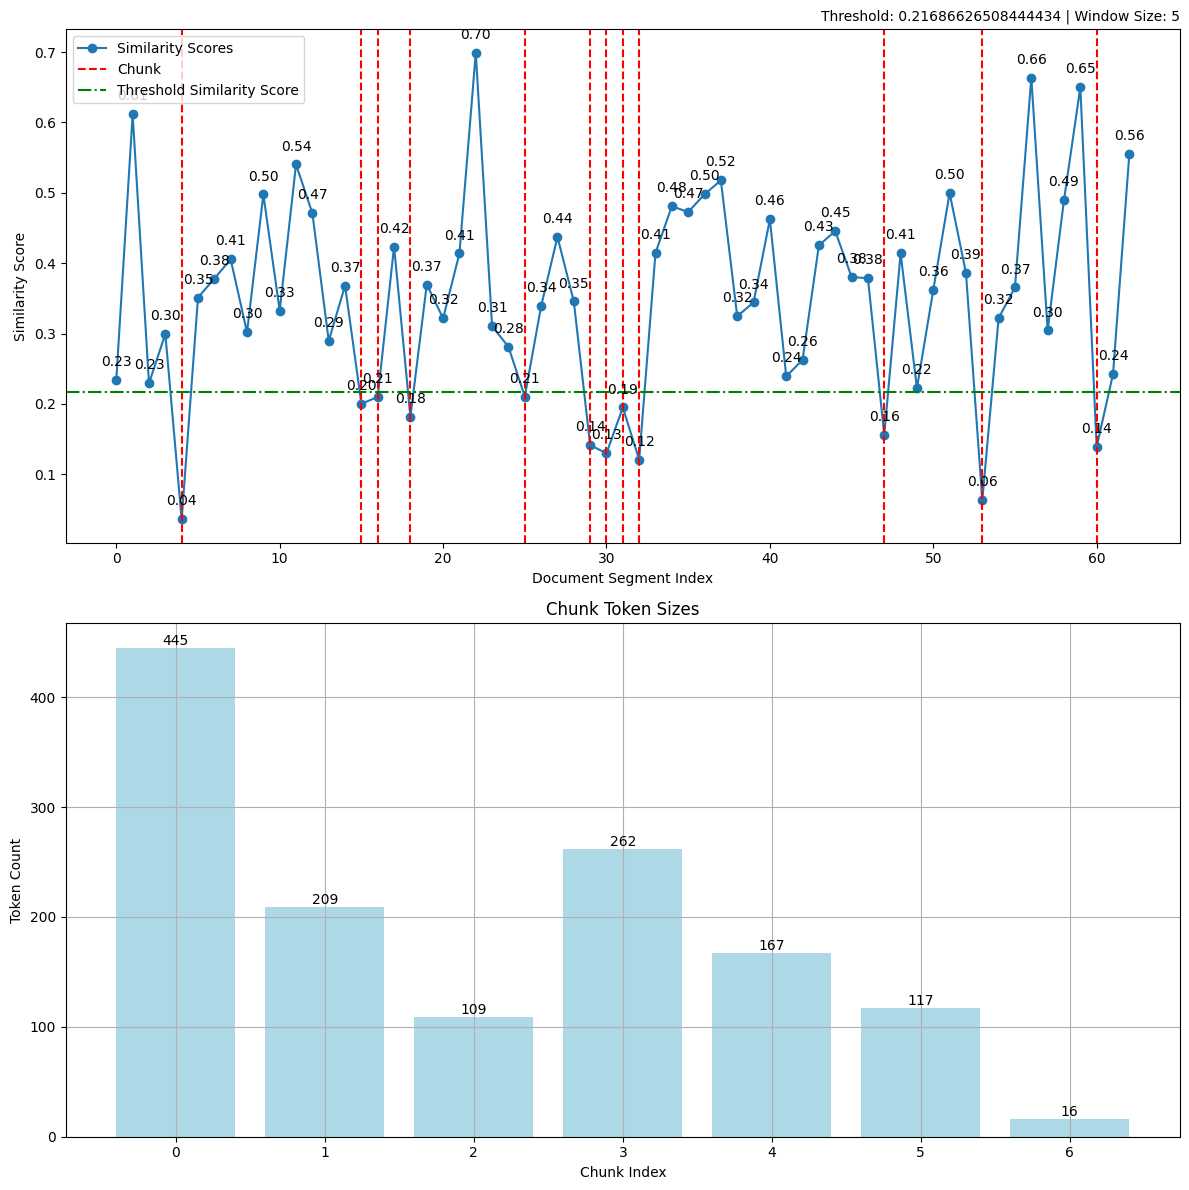

Chunking Statistics:
  - Total Documents: 64
  - Total Chunks: 7
  - Chunks by Threshold: 6
  - Chunks by Max Chunk Size: 0
  - Last Chunk: 1
  - Minimum Token Size of Chunk: 16
  - Maximum Token Size of Chunk: 445
  - Similarity Chunk Ratio: 0.86


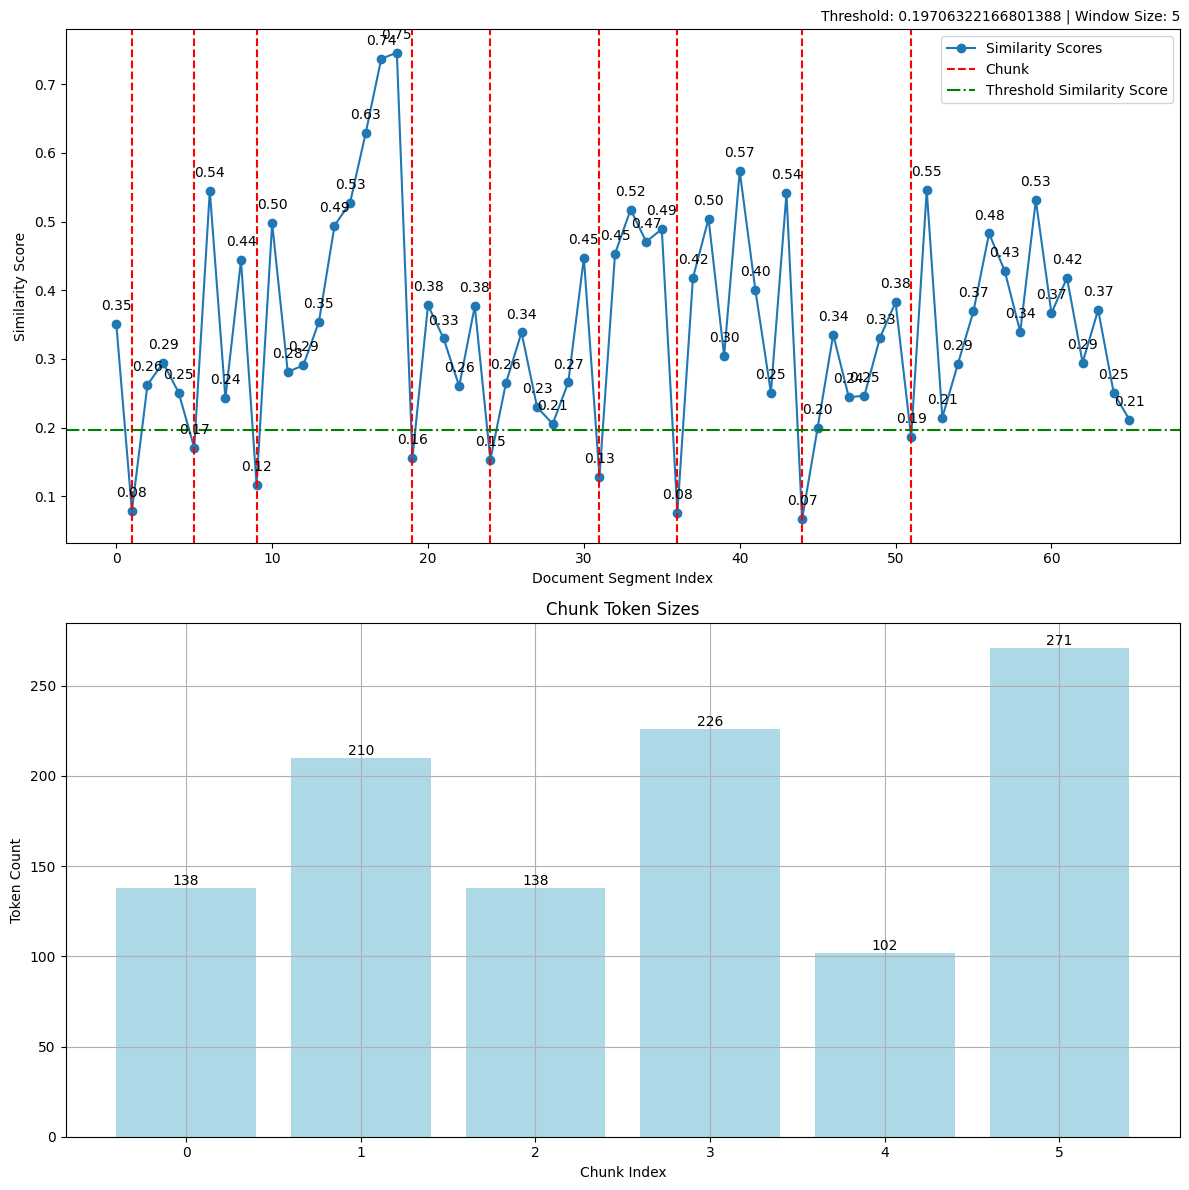

Chunking Statistics:
  - Total Documents: 67
  - Total Chunks: 6
  - Chunks by Threshold: 5
  - Chunks by Max Chunk Size: 0
  - Last Chunk: 1
  - Minimum Token Size of Chunk: 102
  - Maximum Token Size of Chunk: 271
  - Similarity Chunk Ratio: 0.83


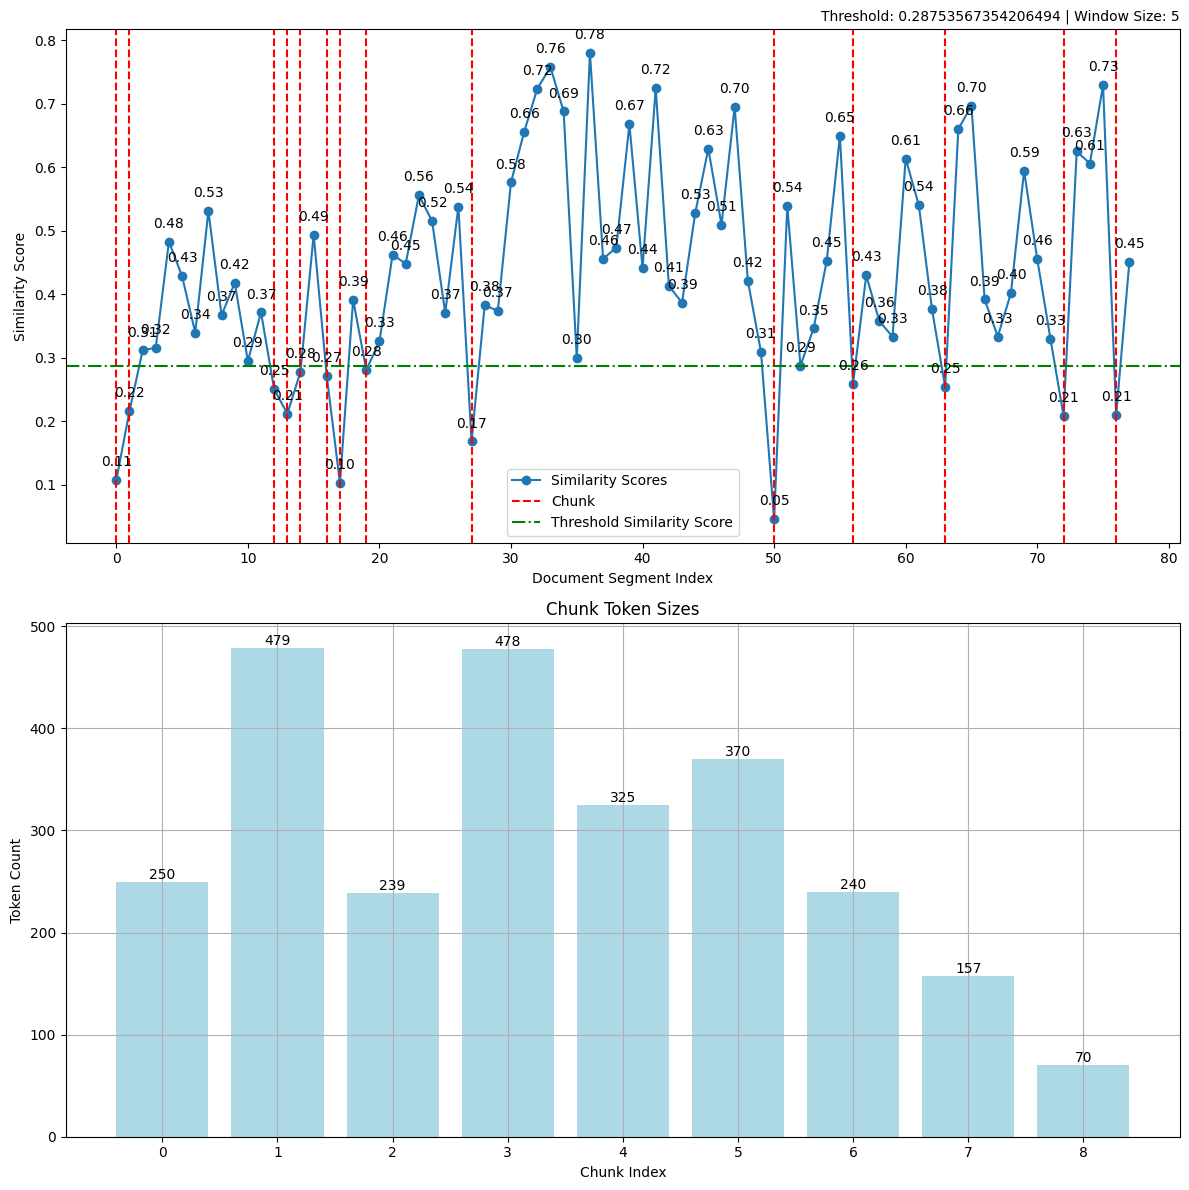

Chunking Statistics:
  - Total Documents: 79
  - Total Chunks: 9
  - Chunks by Threshold: 7
  - Chunks by Max Chunk Size: 1
  - Last Chunk: 1
  - Minimum Token Size of Chunk: 70
  - Maximum Token Size of Chunk: 479
  - Similarity Chunk Ratio: 0.78


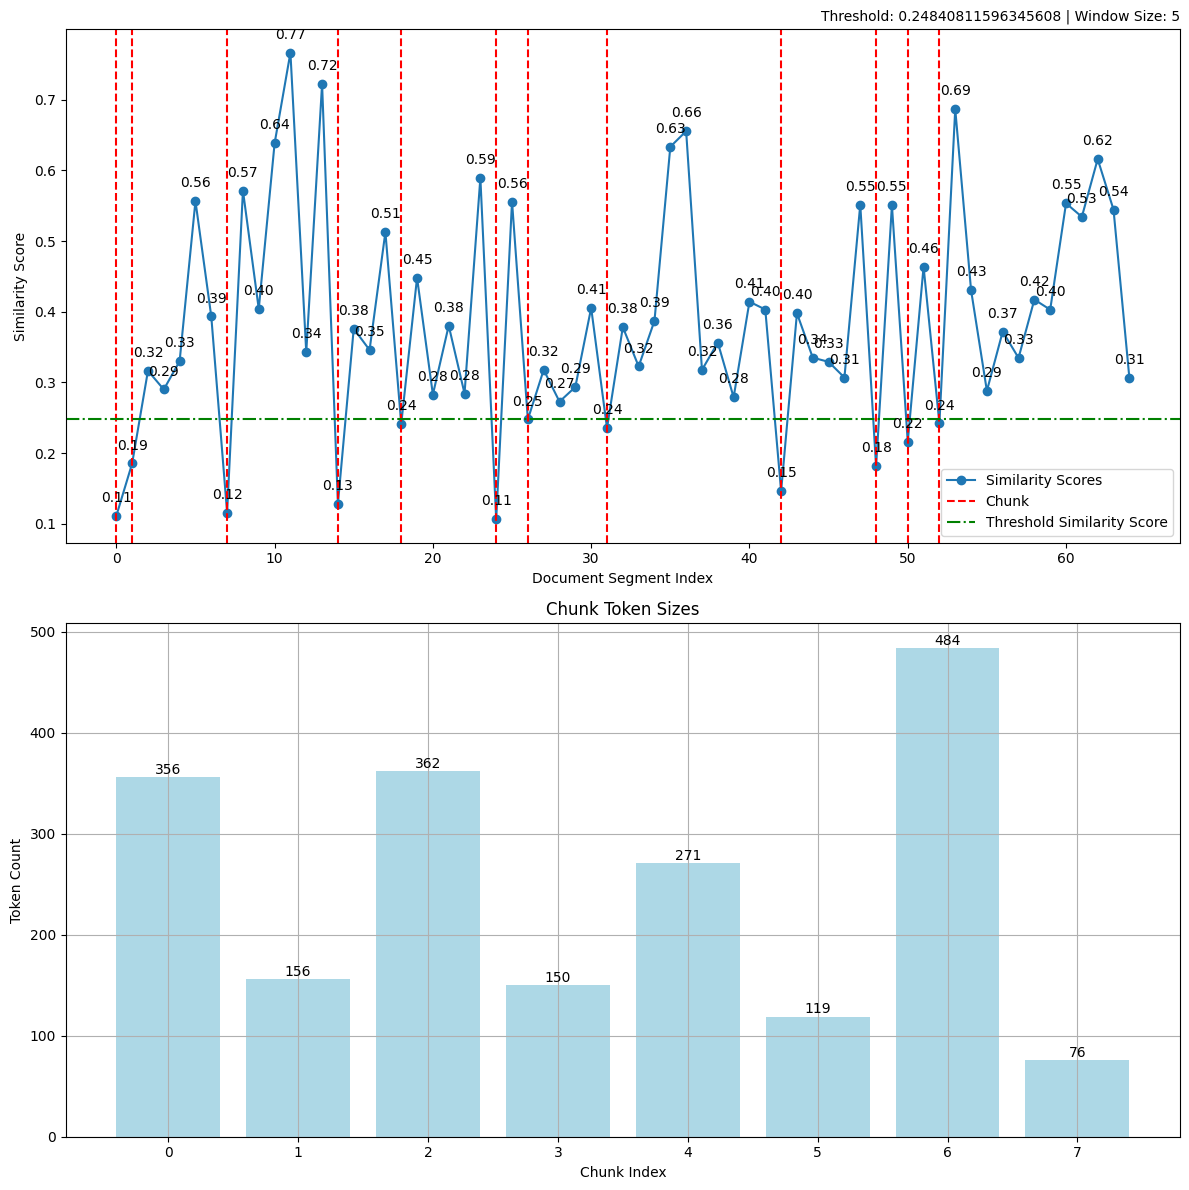

Chunking Statistics:
  - Total Documents: 66
  - Total Chunks: 8
  - Chunks by Threshold: 6
  - Chunks by Max Chunk Size: 1
  - Last Chunk: 1
  - Minimum Token Size of Chunk: 76
  - Maximum Token Size of Chunk: 484
  - Similarity Chunk Ratio: 0.75


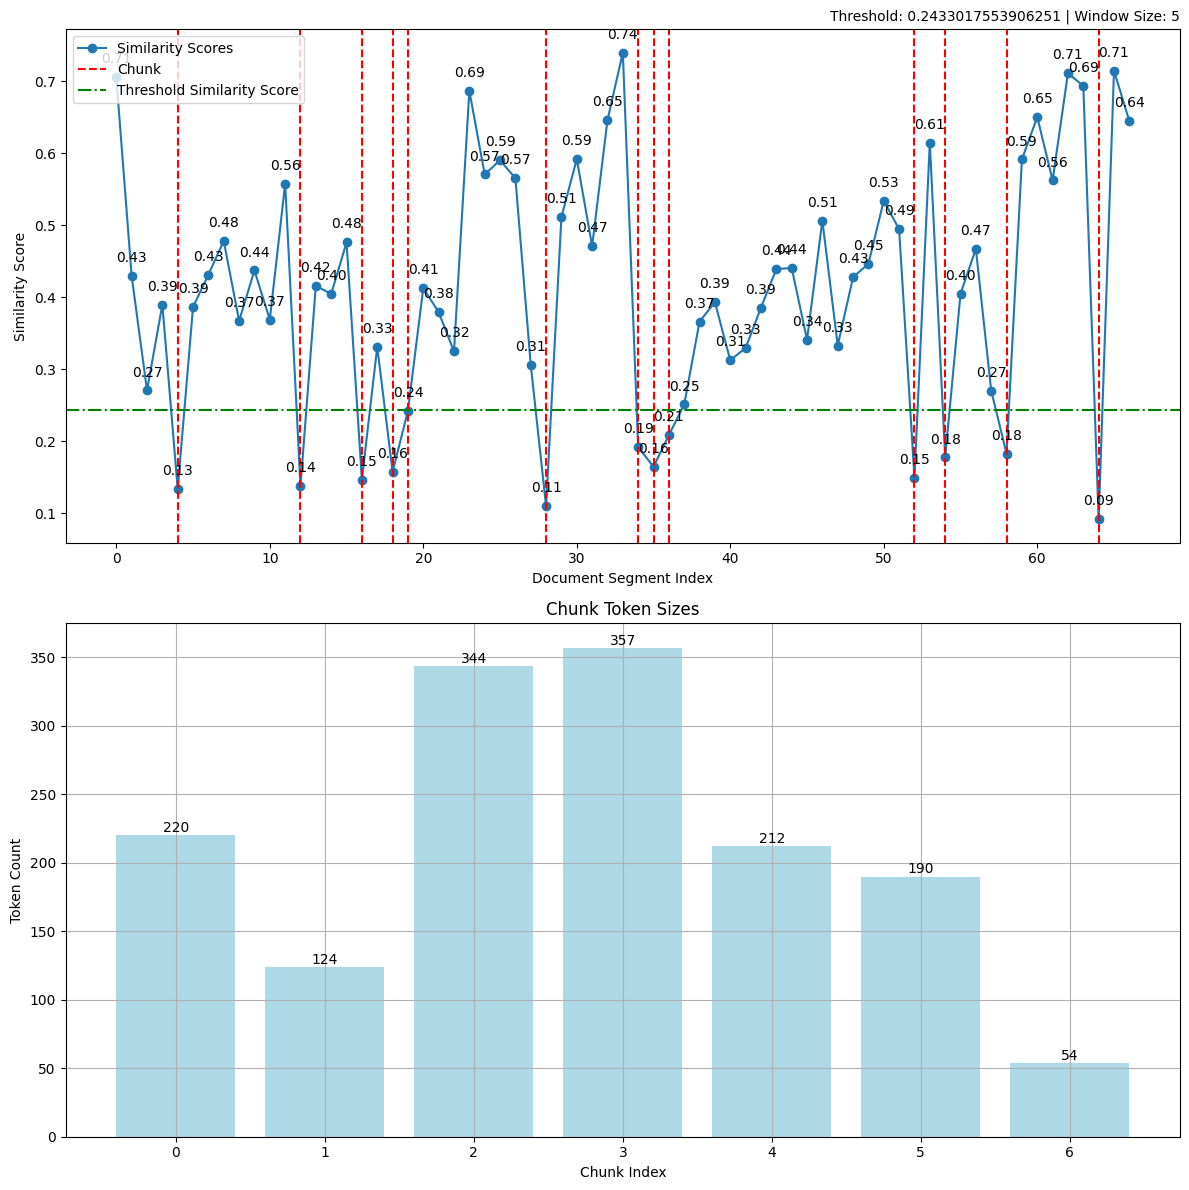

Chunking Statistics:
  - Total Documents: 68
  - Total Chunks: 7
  - Chunks by Threshold: 6
  - Chunks by Max Chunk Size: 0
  - Last Chunk: 1
  - Minimum Token Size of Chunk: 54
  - Maximum Token Size of Chunk: 357
  - Similarity Chunk Ratio: 0.86


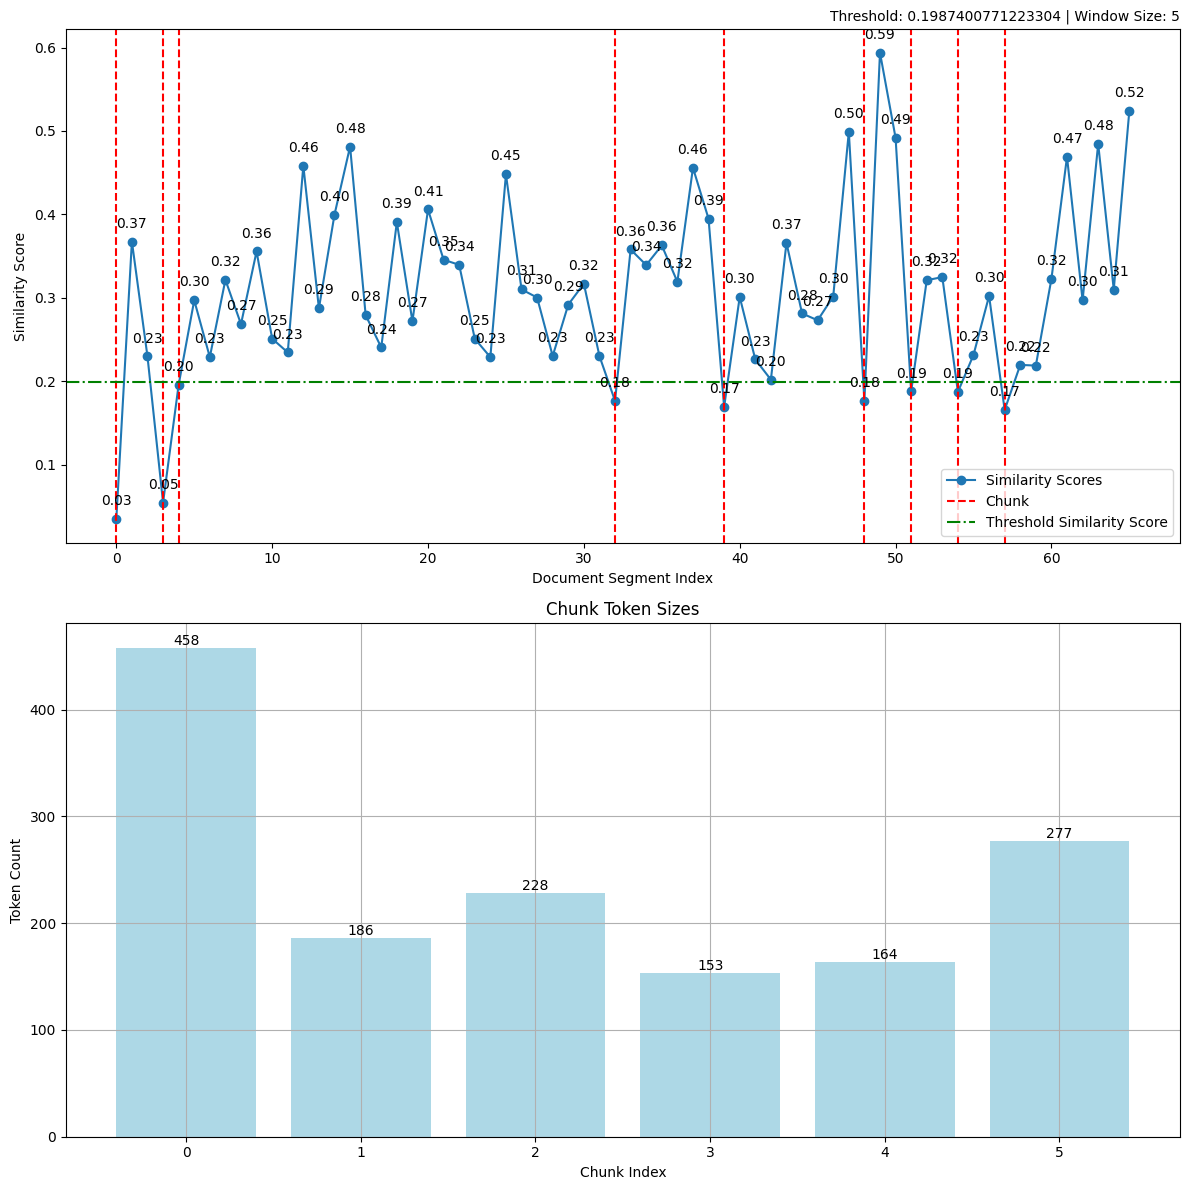

Chunking Statistics:
  - Total Documents: 67
  - Total Chunks: 6
  - Chunks by Threshold: 4
  - Chunks by Max Chunk Size: 1
  - Last Chunk: 1
  - Minimum Token Size of Chunk: 153
  - Maximum Token Size of Chunk: 458
  - Similarity Chunk Ratio: 0.67


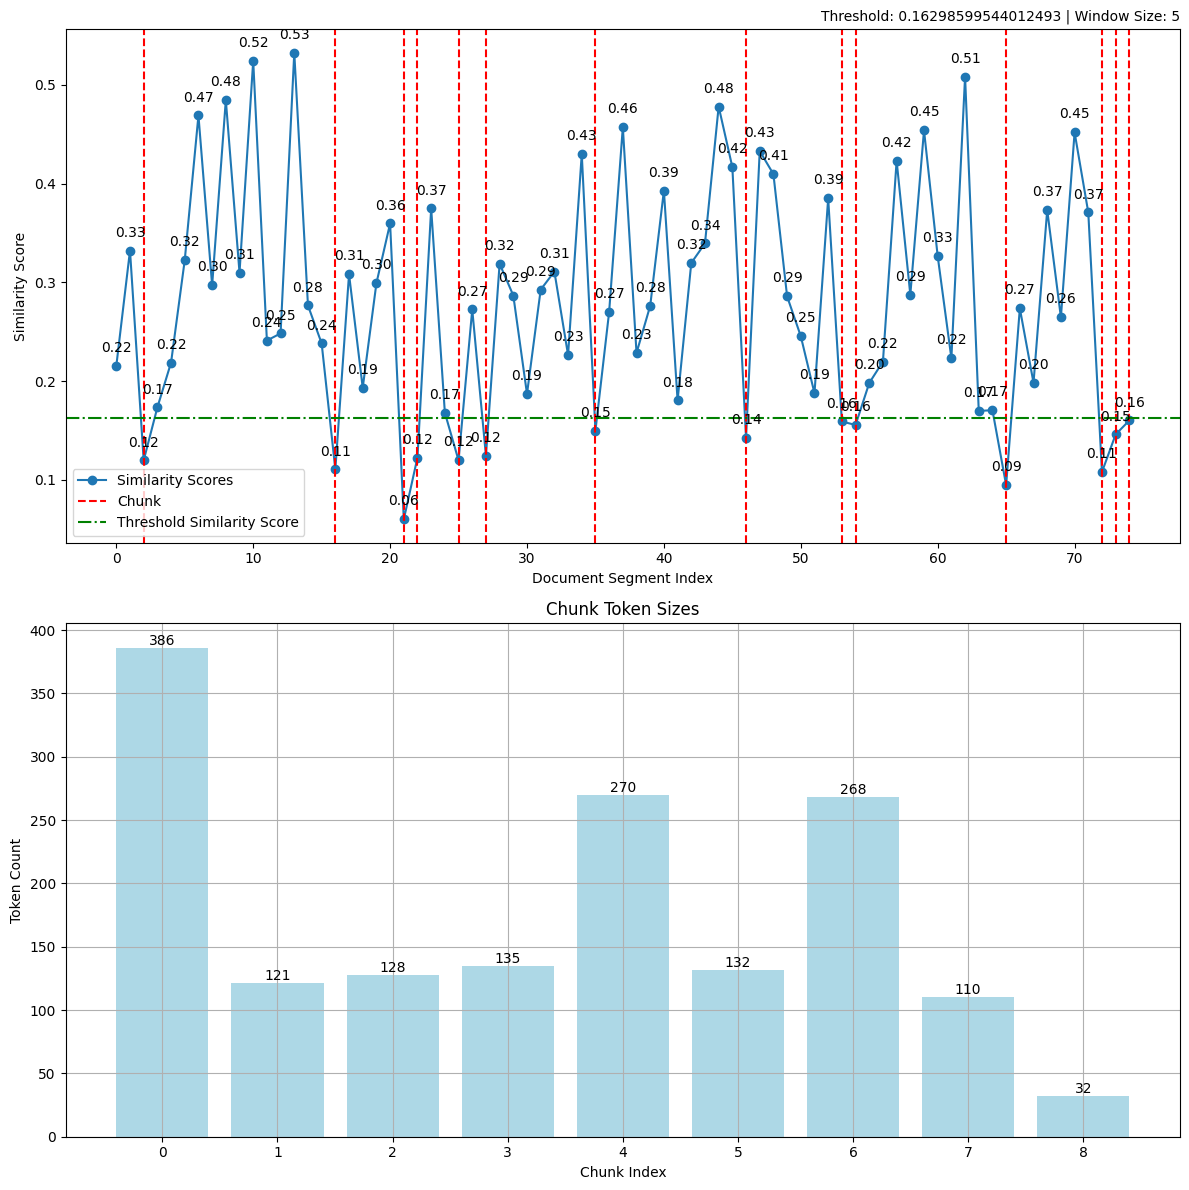

Chunking Statistics:
  - Total Documents: 76
  - Total Chunks: 9
  - Chunks by Threshold: 8
  - Chunks by Max Chunk Size: 0
  - Last Chunk: 1
  - Minimum Token Size of Chunk: 32
  - Maximum Token Size of Chunk: 386
  - Similarity Chunk Ratio: 0.89


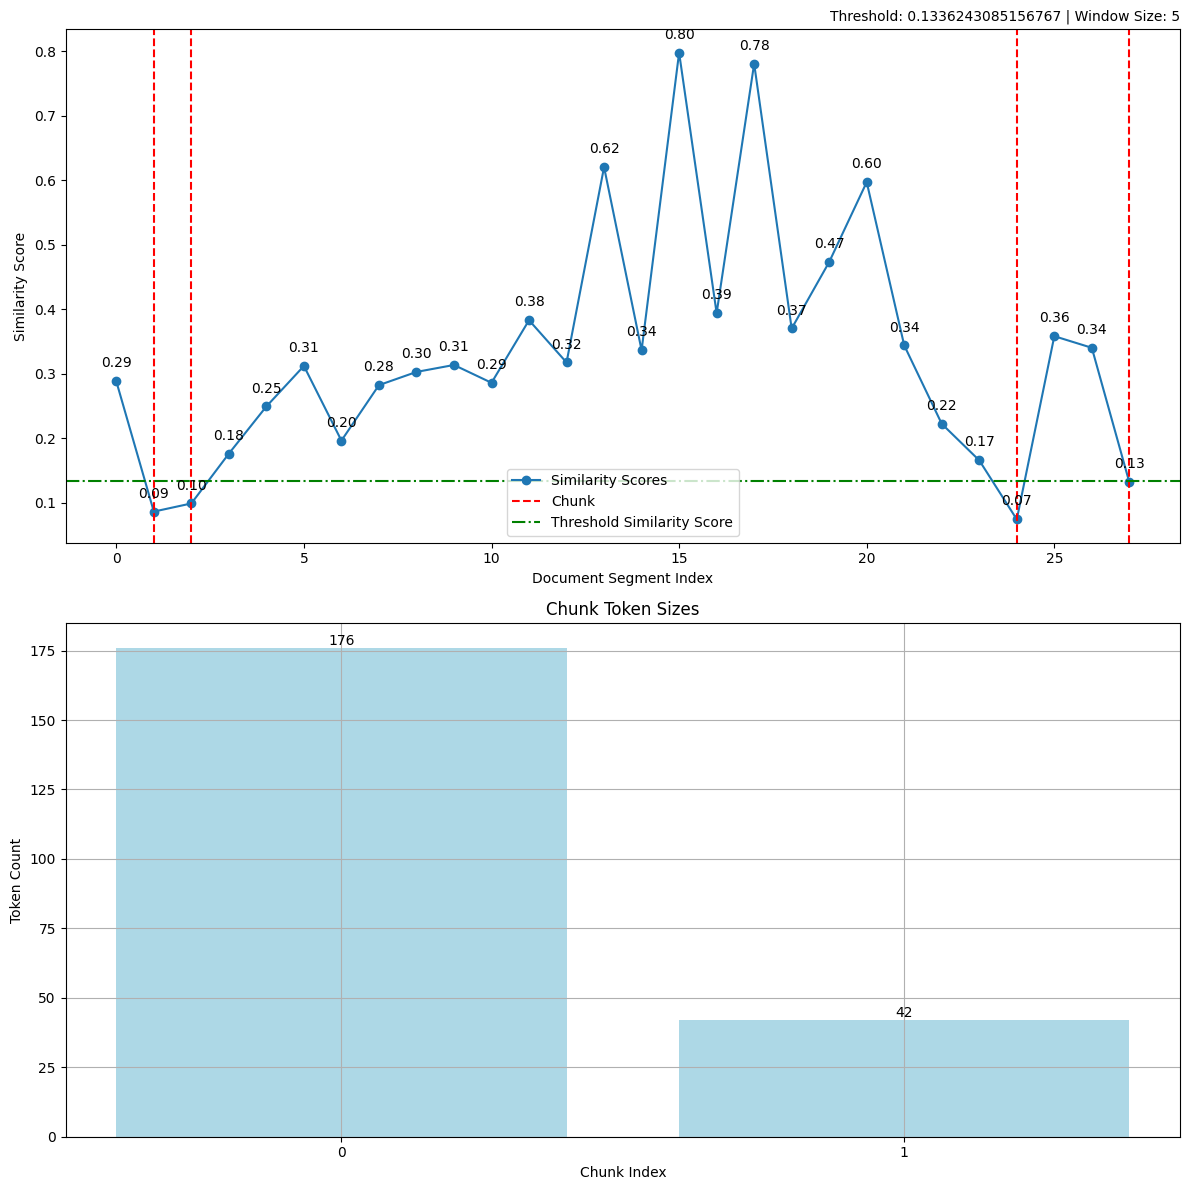

Chunking Statistics:
  - Total Documents: 29
  - Total Chunks: 2
  - Chunks by Threshold: 1
  - Chunks by Max Chunk Size: 0
  - Last Chunk: 1
  - Minimum Token Size of Chunk: 42
  - Maximum Token Size of Chunk: 176
  - Similarity Chunk Ratio: 0.50


In [9]:
chunks_0 = chunker(docs=[dataset["content"][0]])

In [12]:
print(chunks_0[0][:5])

[Chunk(splits=['4 2 0 2', 'n a J 8 ] G L . s c [', '1 v 8 8 0 4 0 . 1 0 4 2 : v i X r a', '# Mixtral of Experts', 'Albert Q.', 'Jiang, Alexandre Sablayrolles, Antoine Roux, Arthur Mensch, Blanche Savary, Chris Bamford, Devendra Singh Chaplot, Diego de las Casas, Emma Bou Hanna, Florian Bressand, Gianna Lengyel, Guillaume Bour, Guillaume Lample, LÃ©lio Renard Lavaud, Lucile Saulnier, Marie-Anne Lachaux, Pierre Stock, Sandeep Subramanian, Sophia Yang, Szymon Antoniak, Teven Le Scao, ThÃ©ophile Gervet, Thibaut Lavril, Thomas Wang, TimothÃ©e Lacroix, William El Sayed', 'Abstract', 'We introduce Mixtral 8x7B, a Sparse Mixture of Experts (SMoE) language model.', 'Mixtral has the same architecture as Mistral 7B, with the difference that each layer is composed of 8 feedforward blocks (i.e. experts).', 'For every token, at each layer, a router network selects two experts to process the current state and combine their outputs.', 'Even though each token only sees two experts, the selected experts